In [3]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.optimize import curve_fit
from scipy.signal import hilbert

In [4]:
N = 5 # number of levels for the oscillator

def dispersive_evolve(w_q, chi, initial_rho, times, expect_ops = None, jump_ops = None):
    a = qt.tensor(qt.destroy(N), qt.qeye(2))  # annihilation operator for the oscillator
    sz = qt.tensor(qt.qeye(N), qt.sigmaz())  # Pauli Z operator for the qubit

    H = 1/2 * w_q * sz + chi * a.dag() * a * sz / 2
    result = qt.mesolve(H, initial_rho, times, c_ops=jump_ops, e_ops=expect_ops)
    return result

def oscillator_evolve(w_c, initial_rho, times, expect_ops = None, jump_ops = None):
    a = qt.destroy(N) # annihilation operator for the oscillator
    H = w_c * a.dag() * a
    result = qt.mesolve(H, initial_rho, times, c_ops=jump_ops, e_ops=expect_ops)
    return result

def projector_onto_states(states):
    # states: list of Qobj state vectors
    P = 0 * (states[0] * states[0].dag())   # zero operator with correct type/dims
    for psi in states:
        P += psi * psi.dag()
    return P

def fit(t, A, T, C):
    return A * np.exp(-t/T) + C

def exp_cosine(t, A, f, phi, tau, of):
    return A * np.cos(2 * np.pi * f * t + phi) * np.exp(-t / tau) + of

def fit_exp_cosine(t, data):
    """Fit A * cos(2*pi*f*t + phi) * exp(-t/tau) + of using Hilbert transform for initial guesses.
    Returns popt = [A, f, phi, tau, of] and pcov."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(data, dtype=float)

    of = float(np.mean(y))
    complex_signal = hilbert(y - of)
    log_z = np.log(np.abs(complex_signal)) + 1j * np.unwrap(np.angle(complex_signal))
    slope, intercept = np.polyfit(t, log_z, 1)
    p0 = [
        float(np.exp(intercept.real)),           # A
        float(slope.imag / (2 * np.pi)),          # f
        float((intercept.imag + np.pi) % (2 * np.pi) - np.pi),  # phi
        float(-1.0 / slope.real),                 # tau
        of,                                        # of
    ]

    popt, _ = curve_fit(exp_cosine, t, y, p0=p0) # do nonlinear fit using initial guess from Hilbert transform
    return popt
    # return p0

def T_phi(nth, kappa, chi):
    """Calculate T_phi for a given thermal photon number nth, cavity decay rate kappa, and dispersive shift chi."""
    gamma_phi = nth * kappa * chi **2 / (kappa **2 + chi **2)
    return 1 / gamma_phi

# test oscillator decay

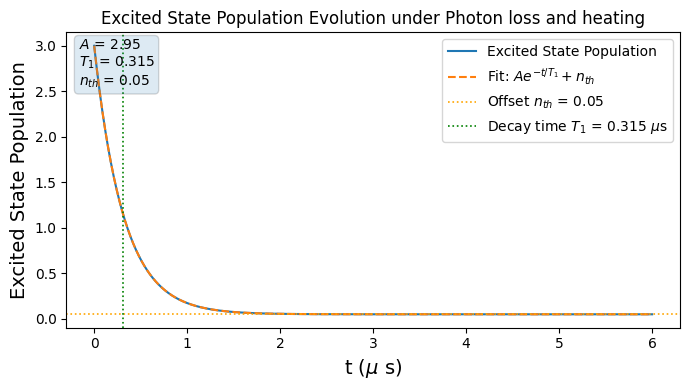

0.31499999999999995


In [8]:
a = qt.destroy(N)

n_th = 0.05 # mean thermal photon number
gamma_loss = 1/0.3 # photon loss rate in MHz
gamma_gain = n_th * gamma_loss / (1 + n_th) # photon gain rate in MHz

tau = np.linspace(0, 6, 1000) # us units
rho_initial = qt.fock_dm(N, 3)


result = oscillator_evolve(2 * np.pi * 1, rho_initial, tau, expect_ops= a.dag() * a, jump_ops=[np.sqrt(gamma_loss)*a, np.sqrt(gamma_gain)*a.dag()]) # start in initial dm and find the expectation value of the number operator at each time step

expect = result.expect[0]

# initial guesses
A0 = expect[0] - expect[-1]
T0 = tau[-1]    
C0 = expect[-1]
p0 = [A0, T0, C0]

bounds = ([-2 * np.abs(A0), 0, 0], [np.inf, np.inf, 2 * np.abs(C0)])

# Fit the data to the model
popt, _ = curve_fit(fit, tau, expect, p0=p0, bounds=bounds)
A_fit, T_fit, C_fit = popt

fit_curve = fit(tau, *popt) # compute the fitted curve for plotting

plt.figure(figsize=(7, 4))
plt.plot(tau, expect, label='Excited State Population')
plt.plot(tau, fit_curve, '--', label=r'Fit: $A e^{-t/T_1} + n_{{th}}$')
plt.axhline(C_fit, linestyle=':', linewidth=1.2, label=rf'Offset $n_{{th}}$ = {C_fit:.4g}', color='orange')
plt.axvline(T_fit, linestyle=':', linewidth=1.2, label=rf'Decay time $T_1$ = {T_fit:.4g} $\mu$s', color='green')

txt = (
    rf"$A$ = {A_fit:.4g}" "\n"
    rf"$T_1$ = {T_fit:.4g}" "\n"
    rf"$n_{{th}}$ = {C_fit:.4g}"
)
plt.text(
    0.02, 0.98, txt,
    transform=plt.gca().transAxes,
    va='top', ha='left',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.xlabel(r't ($\mu$ s)', fontsize=14)
plt.ylabel('Excited State Population', fontsize=14)
plt.title(r'Excited State Population Evolution under Photon loss and heating')
plt.legend()
plt.tight_layout()
plt.show()

print(1/ (gamma_loss - gamma_gain)) # theoretical T1 time in microseconds

# (a) qubit ramsey

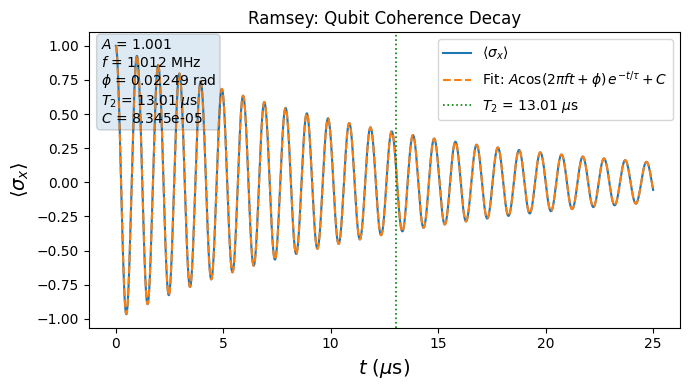

In [30]:
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sz = qt.tensor(qt.qeye(N), qt.sigmaz())
sx = qt.tensor(qt.qeye(N), qt.sigmax())

n_th = 0.05
gamma_loss = 1/0.3
gamma_gain = n_th * gamma_loss / (1 + n_th)

plus_x = (qt.basis(2, 0) + qt.basis(2, 1)).unit()

tau = np.linspace(0, 25, 100000)  # us units
rho_initial = qt.tensor(qt.thermal_dm(N, n_th), projector_onto_states([plus_x]))

result = dispersive_evolve(2 * np.pi * 1, 2 * np.pi * 0.5, rho_initial, tau, expect_ops=sx, jump_ops=[np.sqrt(gamma_loss)*a, np.sqrt(gamma_gain)*a.dag()])
expect = result.expect[0]

# fit
popt = fit_exp_cosine(tau, expect)
A_fit, f_fit, phi_fit, tau_fit, of_fit = popt
fit_curve = A_fit * np.cos(2*np.pi*f_fit*tau + phi_fit) * np.exp(-tau/tau_fit) + of_fit

# plot
plt.figure(figsize=(7, 4))
plt.plot(tau, expect, label=r'$\langle\sigma_x\rangle$')
plt.plot(tau, fit_curve, '--', label=r'Fit: $A\cos(2\pi f t + \phi)\,e^{-t/\tau} + C$')
plt.axvline(tau_fit, linestyle=':', linewidth=1.2, label=rf'$T_2$ = {tau_fit:.4g} $\mu$s', color='green')

plt.text(
    0.02, 0.98,
    rf"$A$ = {A_fit:.4g}" "\n"
    rf"$f$ = {f_fit:.4g} MHz" "\n"
    rf"$\phi$ = {phi_fit:.4g} rad" "\n"
    rf"$T_2$ = {tau_fit:.4g} $\mu$s" "\n"
    rf"$C$ = {of_fit:.4g}",
    transform=plt.gca().transAxes, va='top', ha='left',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.xlabel(r'$t$ ($\mu$s)', fontsize=14)
plt.ylabel(r'$\langle\sigma_x\rangle$', fontsize=14)
plt.title('Ramsey: Qubit Coherence Decay')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
print(f"T_phi = {T_phi(n_th, gamma_loss, 2 * np.pi * 0.5):.4f} microseconds") # theoretical T_phi in microseconds

T_phi = 12.7547 microseconds


# b 

In [5]:
gamma_loss = 6 * np.pi
chi = gamma_loss
T_phi = 1000

n_th = (chi ** 2 + gamma_loss ** 2) / (chi ** 2 * gamma_loss * T_phi)
print(f"n_th = {n_th:.12f}")

n_th = 0.000106103295


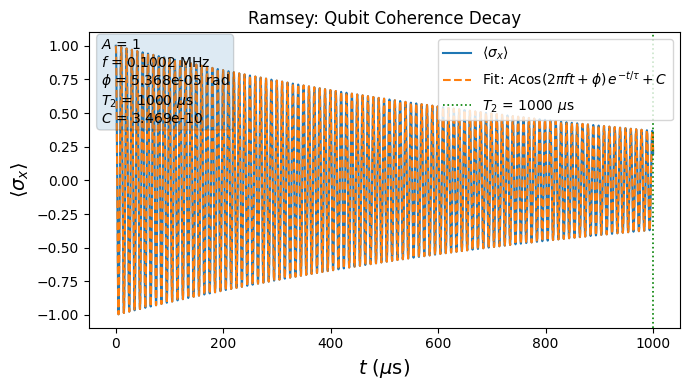

In [10]:
a = qt.tensor(qt.destroy(N), qt.qeye(2))
sz = qt.tensor(qt.qeye(N), qt.sigmaz())
sx = qt.tensor(qt.qeye(N), qt.sigmax())

gamma_gain = n_th * gamma_loss / (1 + n_th)

plus_x = (qt.basis(2, 0) + qt.basis(2, 1)).unit()

tau = np.linspace(0, 1000, 10000)  # us units
rho_initial = qt.tensor(qt.thermal_dm(N, n_th), projector_onto_states([plus_x]))

result = dispersive_evolve(2 * np.pi * 0.1, chi, rho_initial, tau, expect_ops=sx, jump_ops=[np.sqrt(gamma_loss)*a, np.sqrt(gamma_gain)*a.dag()])
expect = result.expect[0]

# fit
popt = fit_exp_cosine(tau, expect)
A_fit, f_fit, phi_fit, tau_fit, of_fit = popt
fit_curve = A_fit * np.cos(2*np.pi*f_fit*tau + phi_fit) * np.exp(-tau/tau_fit) + of_fit

# plot
plt.figure(figsize=(7, 4))
plt.plot(tau, expect, label=r'$\langle\sigma_x\rangle$')
plt.plot(tau, fit_curve, '--', label=r'Fit: $A\cos(2\pi f t + \phi)\,e^{-t/\tau} + C$')
plt.axvline(tau_fit, linestyle=':', linewidth=1.2, label=rf'$T_2$ = {tau_fit:.4g} $\mu$s', color='green')

plt.text(
    0.02, 0.98,
    rf"$A$ = {A_fit:.4g}" "\n"
    rf"$f$ = {f_fit:.4g} MHz" "\n"
    rf"$\phi$ = {phi_fit:.4g} rad" "\n"
    rf"$T_2$ = {tau_fit:.4g} $\mu$s" "\n"
    rf"$C$ = {of_fit:.4g}",
    transform=plt.gca().transAxes, va='top', ha='left',
    bbox=dict(boxstyle='round', alpha=0.15)
)

plt.xlabel(r'$t$ ($\mu$s)', fontsize=14)
plt.ylabel(r'$\langle\sigma_x\rangle$', fontsize=14)
plt.title('Ramsey: Qubit Coherence Decay')
plt.legend()
plt.tight_layout()
plt.show()